# Stock Price Predictor

This project is about the time series problem, which is stock price prediction. This project particularly focuses on the Gold price prediction.

This project persists on following two predictors:
- Linear Regression
- SVM (Support vector machine)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
%matplotlib inline


In [2]:
stocks = input("Enter the stock's code: ") #Ticker Symbol
data = yf.download(stocks, "2006-01-01", "2026-01-01", auto_adjust=True)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2006-01-03,530.700012,528.500000,518.599976,518.599976,7
2006-01-04,533.900024,533.599976,533.500000,533.599976,8
2006-01-05,526.299988,529.000000,526.000000,529.000000,10
2006-01-06,539.700012,539.700012,539.700012,539.700012,10
2006-01-09,549.099976,539.700012,539.700012,539.700012,10


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
data.tail(20)

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2025-12-03,4199.299805,4234.100098,4195.700195,4215.700195,1897
2025-12-04,4211.799805,4211.799805,4175.000000,4211.000000,616
2025-12-05,4212.899902,4255.700195,4194.500000,4204.100098,533
2025-12-08,4187.200195,4215.799805,4175.500000,4205.500000,318
2025-12-09,4206.700195,4219.700195,4177.700195,4190.700195,660
2025-12-10,4196.399902,4234.500000,4183.600098,4209.000000,692
2025-12-11,4285.500000,4286.899902,4214.299805,4224.000000,528
2025-12-12,4300.100098,4355.000000,4260.000000,4276.399902,1531


In [5]:
data.shape

(5030, 5)

In [6]:
data.isnull().sum()

Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64

In [7]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5030 entries, 2006-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   5030 non-null   float64
 1   (High, GC=F)    5030 non-null   float64
 2   (Low, GC=F)     5030 non-null   float64
 3   (Open, GC=F)    5030 non-null   float64
 4   (Volume, GC=F)  5030 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.8 KB


In [8]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
count,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000
mean,1488.544472,1496.413181,1480.298350,1488.412247,4989.530417
std,634.348587,638.071822,629.914569,633.586995,26649.614830
min,526.299988,528.500000,518.599976,518.599976,0.000000
25%,1167.450012,1172.450043,1160.650024,1167.100006,40.000000
50%,1323.450012,1329.599976,1319.250000,1324.099976,152.000000
75%,1773.574982,1783.099976,1766.225037,1774.750031,539.500000
max,4529.100098,4556.299805,4502.000000,4512.000000,386334.000000


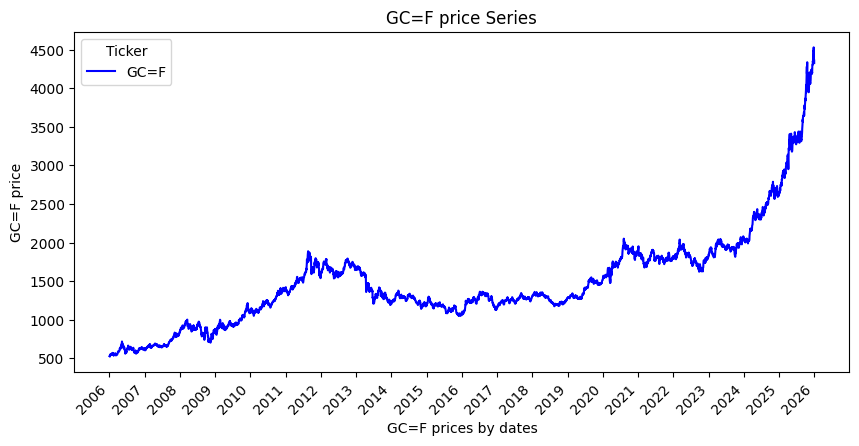

In [9]:
import matplotlib.dates as mdates
data.Close.plot(figsize=(10,5), color = 'b')
plt.ylabel("{} price".format(stocks))
plt.xlabel("{} prices by dates".format(stocks))
plt.title("{} price Series".format(stocks))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))   # every 1 year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='Count'>

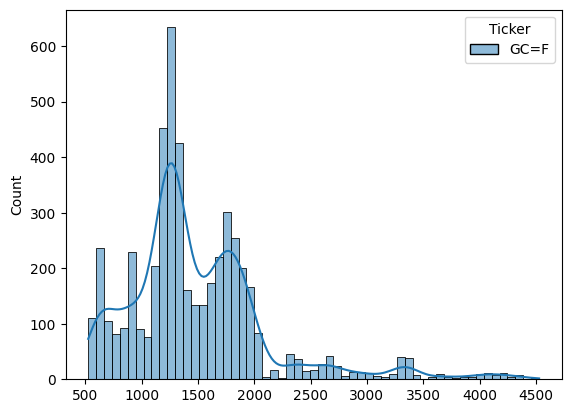

In [10]:
sns.histplot(data["Close"], kde=True)


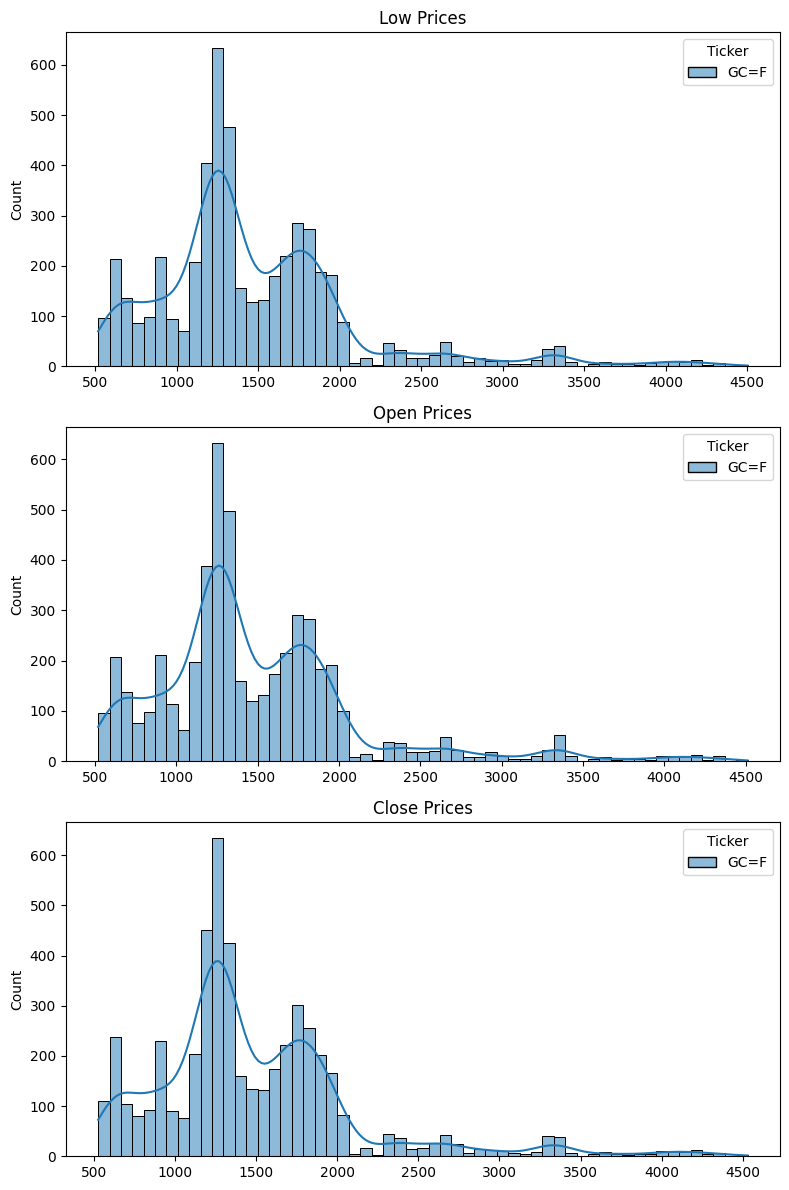

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

sns.histplot(data["Low"], kde=True, ax=axes[0])
axes[0].set_title("Low Prices")

sns.histplot(data["Open"], kde=True, ax=axes[1])
axes[1].set_title("Open Prices")

sns.histplot(data["Close"], kde=True, ax=axes[2])
axes[2].set_title("Close Prices")

plt.tight_layout()
plt.show()

In [12]:
x = data.drop("Close", axis = 1)
y = data["Close"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(x_test.shape)



(4024, 4)
(1006, 4)
(4024, 1)
(1006, 4)


In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
pred = lr.predict(x_test)

Calculating the cost function

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

def calculate_metrics(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_scor = r2_score(y_test, y_pred)
    
    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("r2_score: ", r2_scor)
    
calculate_metrics(y_test, pred)
    

MSE:  31.527700915168815
RMSE:  5.614953331521894
r2_score:  0.999918677862802


In [15]:
from sklearn.linear_model import Lasso, Ridge

la = Lasso().fit(x_train, y_train)
ri = Ridge().fit(x_train, y_train)

la_p = la.predict(x_test)
ri_p = ri.predict(x_test)


c:\Users\PMYLS\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.636e+05, tolerance: 1.634e+05
  model = cd_fast.enet_coordinate_descent(


In [16]:
calculate_metrics(y_test, la_p)

MSE:  86.11798121531366
RMSE:  9.279977436142486
r2_score:  0.999777868411577


In [17]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR()
param_grid = {'C': [0.1, 1, 10, 100, 100],
              'gamma': [1, 1.0, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=3)
grid.fit(x_train, y_train)
print(grid)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\PMYLS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.097 total time=   1.1s


c:\Users\PMYLS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.035 total time=   1.1s


...

[CV 4/5] END ...C=100, gamma=0.0001, kernel=rbf;, score=0.496 total time=   1.2s


c:\Users\PMYLS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END ...C=100, gamma=0.0001, kernel=rbf;, score=0.466 total time=   1.2s


c:\Users\PMYLS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 100],
                         'gamma': [1, 1.0, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)


Manually Selecting the hyper-parameters

In [18]:
svr = SVR(C=10, gamma=0.01, kernel='rbf')
svr.fit(x_train, y_train.squeeze())
svr_pred = svr.predict(x_test)

Serializing the model

In [19]:
import joblib
joblib.dump(ri, 'model.pkl')
ridge_from_joblib = model = joblib.load("model.pkl")